## Step 1: Install Libraries

In [18]:
pip install numpy opencv-python matplotlib scikit-learn tensorflow

## Step 2: Import Libraries

In [19]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

## Step 3: Load Images

In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
import os
import cv2
import numpy as np

images = []
labels = []
class_names = [] # List to store unique class names (e.g., 'Aamir', 'Amitabh', 'Iris' if it had images)
class_name_to_label_id = {} # Map class names to integer labels

dataset_path = "/content/drive/MyDrive/dataset (1)"

# Define allowed image extensions
IMG_EXTENSIONS = ('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff', '.webp')

# Use os.walk to recursively find all image files and assign labels
for root, dirs, files in os.walk(dataset_path):
    for file_name in files:
        if file_name.lower().endswith(IMG_EXTENSIONS):
            img_path = os.path.join(root, file_name)

            # The class name is the name of the immediate parent directory of the image file.
            # E.g., for '/dataset (1)/faces/Aamir/img.jpg', the class is 'Aamir'.
            # For '/dataset (1)/Iris/img.jpg', the class would be 'Iris'.
            class_name = os.path.basename(root)

            # Assign a unique integer label to each unique class name
            if class_name not in class_name_to_label_id:
                class_name_to_label_id[class_name] = len(class_names)
                class_names.append(class_name)

            current_label = class_name_to_label_id[class_name]

            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                print(f"Warning: Could not read image file: {img_path}. Skipping.")
                continue

            img = cv2.resize(img, (100, 100))
            images.append(img.flatten())
            labels.append(current_label)

X = np.array(images)
y = np.array(labels)

print(f"Successfully loaded {len(images)} images from {len(class_names)} classes.")
print(f"Classes and their assigned labels: {class_name_to_label_id}")

Successfully loaded 450 images from 9 classes.
Classes and their assigned labels: {'Ileana': 0, 'Disha': 1, 'Farhan': 2, 'Deepika': 3, 'Amitabh': 4, 'Alia': 5, 'Akshay': 6, 'Aamir': 7, 'Ajay': 8}


## Step 4: Normalize Images

In [22]:
X = X.astype("float32") / 255.0

## Step 5: Train-Test Split (60%-40%)

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(270, 10000)
(180, 10000)


## Step 6: PCA (Eigenfaces)

In [24]:
k = 100

pca = PCA(n_components=k)

X_train_pca = pca.fit_transform(X_train)

X_test_pca = pca.transform(X_test)

print(X_train_pca.shape)

(270, 100)


## Step 7: Convert Labels

In [25]:
num_classes = len(np.unique(y))

y_train_cat = to_categorical(y_train, num_classes)

y_test_cat = to_categorical(y_test, num_classes)

## Step 7: Build ANN

In [26]:
model = Sequential()

model.add(Dense(256, activation='relu', input_shape=(k,)))
model.add(Dropout(0.3))

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(num_classes, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,913 (234.04 KB)

 Trainable params: 59,913 (234.04 KB)

 Non-trainable params: 0 (0.00 B)

## Step 8: Train ANN

In [27]:
history = model.fit(
    X_train_pca,
    y_train_cat,
    epochs=50,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.1759 - loss: 2.8931 - val_accuracy: 0.2778 - val_loss: 2.1572
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3009 - loss: 2.0907 - val_accuracy: 0.3148 - val_loss: 1.8269
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4444 - loss: 1.5761 - val_accuracy: 0.4444 - val_loss: 1.6646
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5787 - loss: 1.2270 - val_accuracy: 0.4259 - val_loss: 1.6170
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6157 - loss: 1.0967 - val_accuracy: 0.4815 - val_loss: 1.5047
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7454 - loss: 0.8582 - val_accuracy: 0.5000 - val_loss: 1.3992
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7176 - loss: 0.8429 - val_accuracy: 0.5185 - val_loss: 1.3808
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8009 - loss: 0.6491 - val_accuracy: 0.4815 - v

## Step 9: Test Accuracy

In [28]:
pred = model.predict(X_test_pca)

y_pred = np.argmax(pred, axis=1)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy =", accuracy)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Accuracy = 0.6611111111111111


## Step 10: Accuracy Graph

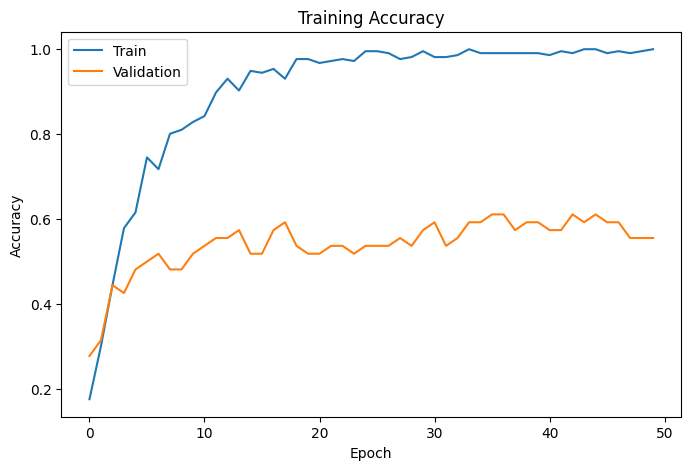

In [29]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

## Step 11: Accuracy vs K Graph

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


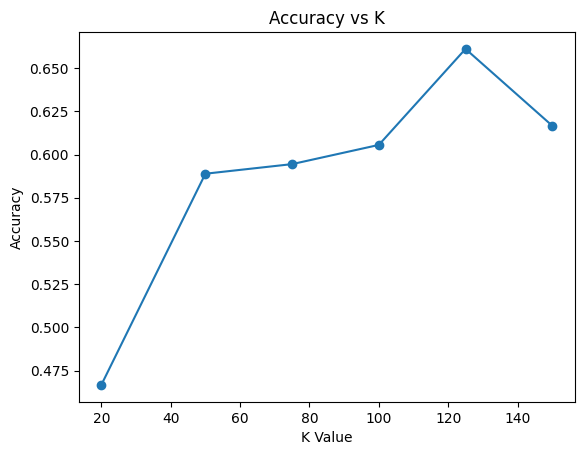

In [30]:
k_values = [20,50,75,100,125,150]

accuracy_list = []

for k in k_values:

    pca = PCA(n_components=k)

    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    model = Sequential([
        Dense(128, activation='relu', input_shape=(k,)),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        X_train_pca,
        y_train_cat,
        epochs=10,
        verbose=0
    )

    pred = np.argmax(model.predict(X_test_pca), axis=1)

    acc = accuracy_score(y_test, pred)

    accuracy_list.append(acc)

plt.plot(k_values, accuracy_list, marker='o')
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K")
plt.show()

## Step 12: Save Model

In [31]:
model.save("pca_ann_model.h5")